# Практика к занятию 2. Линейные модели: регрессия.

**Что попробуем:**
- реализовать линейную регрессию через МНК,
- реализовать линейную регрессию через градиентный спуск,
- и сравнить их с реализациями из sklearn по различным метрикам качества.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# данные, предобработка, моделирование
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor

# метрики
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_log_error,
    max_error,
    r2_score
)

np.random.seed(28)

## 0. Загрузка данных и вспомогательные функции.

In [32]:
# Загрузим набор данных California Housing
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names
print(X.shape)
print(feature_names)
print(type(X), type(y))

(20640, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [33]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [35]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: >

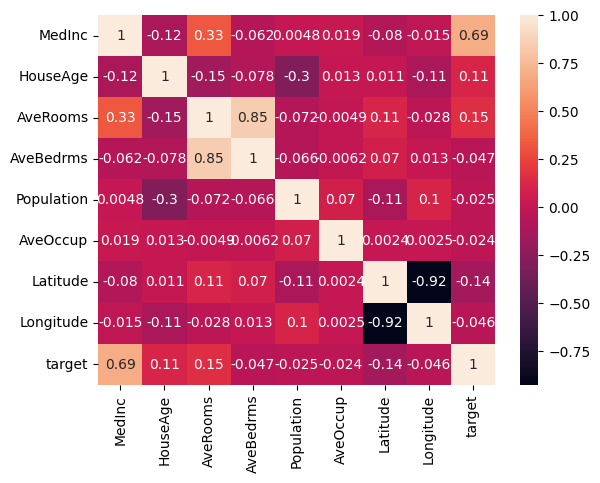

In [36]:
sns.heatmap(df.corr(), annot=True)

In [37]:
X = df.drop(["target", "Longitude", "AveBedrms"], axis=1)

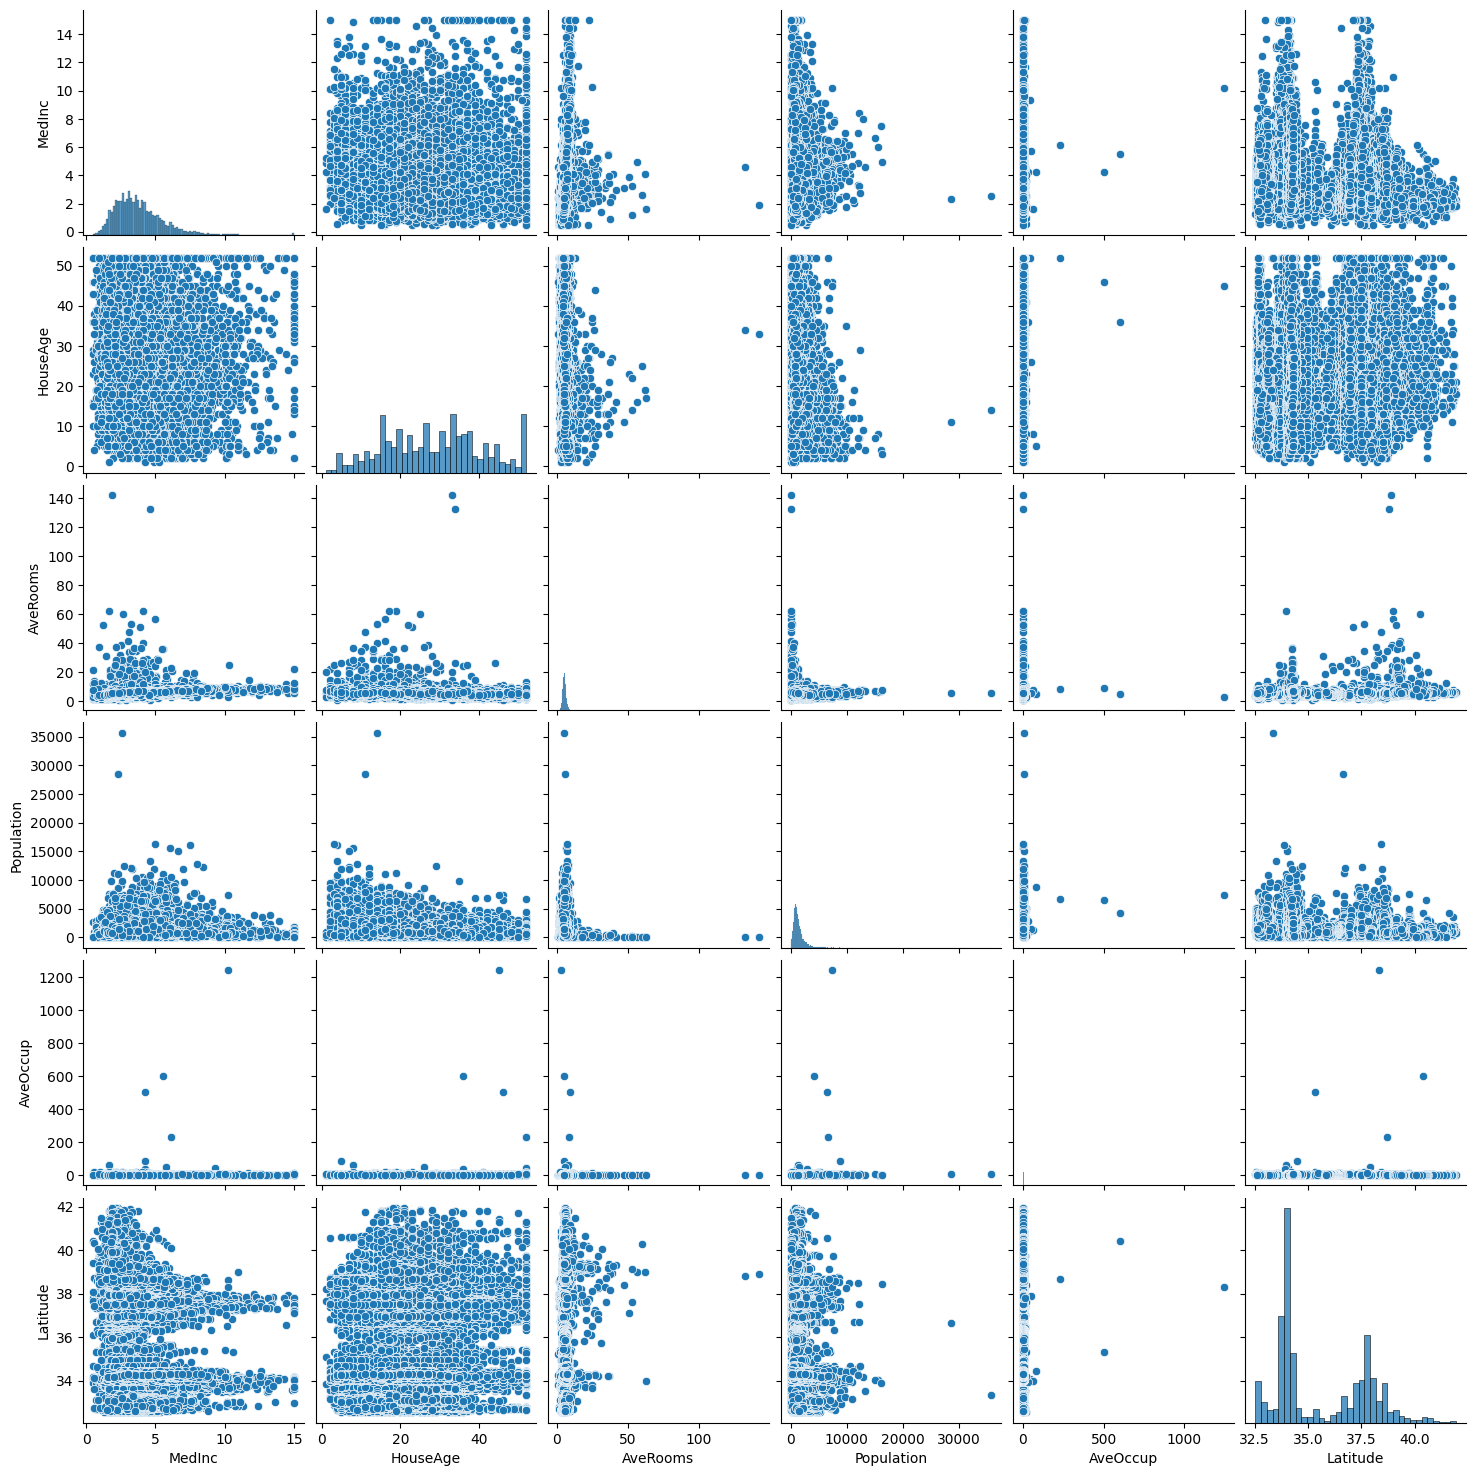

In [38]:
sns.pairplot(X)

In [ ]:
# Разделим на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Стандартизируем данные
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
print(X_train, '\n')
X_test = scaler.transform(X_test)
print(X_test)

# Добавим признак-смещение (bias)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [40]:
def predict(X, weights):
    """
    Расчёт предсказания модели
    """
    return X @ weights

def mse_loss(y_true, y_pred):
    """
    Расчёт значения функции ошибки MSE
    """
    return np.mean((y_true - y_pred) ** 2)

In [41]:
def plot_history(losses):
    """
    Визуализация графика сходимости
    (значение loss в зависимости от номера итерации)
    """
    plt.plot(losses)
    plt.xlabel("Iteration")
    plt.ylabel("MSE Loss")
    plt.title("График сходимости градиентного спуска")
    plt.grid(True)
    plt.show()

In [42]:
def regression_metrics(y_true, y_pred):
    """
    Вычисляет метрики качества линейной регрессии.

    Parameters
    ----------
    y_true : array-like
        Реальные значения (таргет).
    y_pred : array-like
        Предсказанные значения.

    Returns
    -------
    dict
        Словарь с метриками: MSE, RMSE, MAE, MAPE, MSLE, MaxError, R².
    """

    # MSE
    mse = mean_squared_error(y_true, y_pred)

    # RMSE
    rmse = np.sqrt(mse)

    # MAE
    mae = mean_absolute_error(y_true, y_pred)

    # MAPE (может вернуть inf, если y_true содержит нули)
    try:
        mape = mean_absolute_percentage_error(y_true, y_pred)
    except:
        mape = np.nan

    # MSLE (работает только если y_true, y_pred >= 0)
    try:
        msle = mean_squared_log_error(y_true, y_pred)
    except:
        msle = np.nan

    # MaxError
    max_err = max_error(y_true, y_pred)

    # R^2
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "MSLE": msle,
        "MaxError": max_err,
        "R²": r2
    }

## 1. Метод наименьших квадратов.

*Базовая формула:*

$w=(X^TX)^{−1}X^Ty$

In [43]:
def least_squares(X, y):
    """
    Решение задачи линейной регрессии методом МНК (OLS).

    X : np.ndarray, shape (n_samples, n_features)
        Матрица признаков (с уже добавленным столбцом единиц, если нужен bias).
    y : np.ndarray, shape (n_samples,)
        Вектор целевой переменной.

    return:
        weights : np.ndarray, shape (n_features,)
            Вектор весов линейной регрессии.
    """
    xtx_inv = np.linalg.inv(X.T @ X)
    weights = xtx_inv @ X.T @ y
    return weights

In [44]:
# наша реализация вручную
weights_my_lsm = least_squares(X_train, y_train)
print(weights_my_lsm) # веса

# считаем предсказания на train и test
p_my_lsm_train = predict(X_train, weights_my_lsm)
p_my_lsm_test = predict(X_test, weights_my_lsm)

[ 2.07194694  0.83610282  0.22105212 -0.05036069  0.02119718 -0.04873706
 -0.09443353]


In [45]:
# встроенная реализация в sklearn
model_skl_lsm = LinearRegression(fit_intercept=False)
model_skl_lsm.fit(X_train, y_train)
print(model_skl_lsm.coef_) # веса

# считаем предсказания на train и test
p_skl_lsm_train = model_skl_lsm.predict(X_train)
p_skl_lsm_test = model_skl_lsm.predict(X_test)

[ 2.07194694  0.83610282  0.22105212 -0.05036069  0.02119718 -0.04873706
 -0.09443353]


Сделаем предсказание на тренировочных и тестовых данных и сравним качество по основным метрикам регрессии!

In [46]:
y_train.min(), y_train.max()

(np.float64(0.14999), np.float64(5.00001))

In [47]:
0.7972715471833608 / (y_train.max() - y_train.min()) * 100

np.float64(16.438520814004086)

In [48]:
# вручную реализованный МНК
display(regression_metrics(y_train, p_my_lsm_train))
print()
display(regression_metrics(y_test, p_my_lsm_test))

{'MSE': 0.6356419199481499,
 'RMSE': np.float64(0.7972715471833608),
 'MAE': 0.5935766975312613,
 'MAPE': 0.3619529127641517,
 'MSLE': nan,
 'MaxError': np.float64(6.779518500087715),
 'R²': 0.5244970973178325}

{'MSE': 0.6473676847426388,
 'RMSE': np.float64(0.8045916260704177),
 'MAE': 0.5982706370702852,
 'MAPE': 0.36849001240830687,
 'MSLE': 0.06297596182113163,
 'MaxError': np.float64(4.434678122267563),
 'R²': 0.5059804263462322}

In [49]:
# МНК из sklearn
display(regression_metrics(y_train, p_skl_lsm_train))
print()
display(regression_metrics(y_test, p_skl_lsm_test))

{'MSE': 0.6356419199481499,
 'RMSE': np.float64(0.7972715471833608),
 'MAE': 0.5935766975312612,
 'MAPE': 0.3619529127641514,
 'MSLE': nan,
 'MaxError': np.float64(6.779518500087717),
 'R²': 0.5244970973178325}

{'MSE': 0.6473676847426387,
 'RMSE': np.float64(0.8045916260704176),
 'MAE': 0.5982706370702849,
 'MAPE': 0.36849001240830653,
 'MSLE': 0.0629759618211316,
 'MaxError': np.float64(4.434678122267564),
 'R²': 0.5059804263462322}

## 2. Классический градиентный спуск.

*Базовая формула:*

$w_{k+1} = w_k - \eta \cdot \nabla_w L(w_k)$

In [ ]:
def gradient_descent(
    X, y, lr=0.1, n_iter=1000, calc_loss=True, print_loss=True
):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features) # начальное приближение
    losses = []

    for i in range(n_iter):
        # предсказание
        y_pred = predict(X, weights)

        # градиент
        error = y_pred - y
        grad = (2 / n_samples) * X.T @ error

        # обновление весов
        weights -= lr * grad

        # расчёт и сохранение ошибки
        if calc_loss:
            loss = mse_loss(y, y_pred)
            losses.append(loss)

            # промежуточные выводы на экран
            if print_loss and i % 10 == 0:
                print(f"Iteration {i}: MSE = {loss:.4f}")

    return weights, losses

Iteration 0: MSE = 5.6297
Iteration 10: MSE = 5.4333
Iteration 20: MSE = 5.2446
Iteration 30: MSE = 5.0635
Iteration 40: MSE = 4.8896
Iteration 50: MSE = 4.7226
Iteration 60: MSE = 4.5622
Iteration 70: MSE = 4.4082
Iteration 80: MSE = 4.2604
Iteration 90: MSE = 4.1184
Iteration 100: MSE = 3.9820
Iteration 110: MSE = 3.8511
Iteration 120: MSE = 3.7253
Iteration 130: MSE = 3.6045
Iteration 140: MSE = 3.4885
Iteration 150: MSE = 3.3771
Iteration 160: MSE = 3.2701
Iteration 170: MSE = 3.1674
Iteration 180: MSE = 3.0687
Iteration 190: MSE = 2.9739
Iteration 200: MSE = 2.8828
Iteration 210: MSE = 2.7953
Iteration 220: MSE = 2.7113
Iteration 230: MSE = 2.6306
Iteration 240: MSE = 2.5531
Iteration 250: MSE = 2.4786
Iteration 260: MSE = 2.4071
Iteration 270: MSE = 2.3383
Iteration 280: MSE = 2.2723
Iteration 290: MSE = 2.2089
Iteration 300: MSE = 2.1479
Iteration 310: MSE = 2.0894
Iteration 320: MSE = 2.0331
Iteration 330: MSE = 1.9791
Iteration 340: MSE = 1.9272
Iteration 350: MSE = 1.8773
Ite

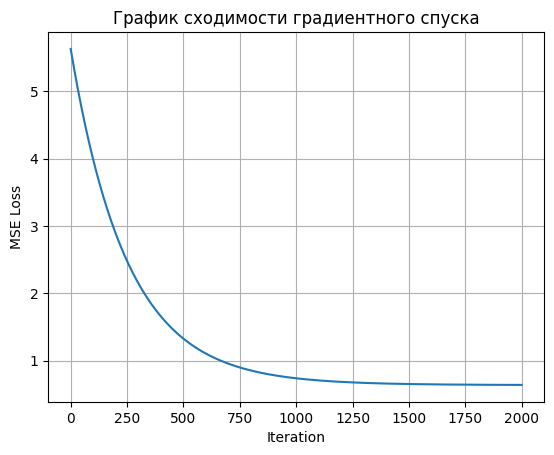

[ 2.0341496   0.80066522  0.20968366 -0.02420934  0.01374893 -0.04415035
 -0.10578692]


In [62]:
weights, losses = gradient_descent(
    X_train, y_train, lr=0.001, n_iter=2000, calc_loss=True, print_loss=True
)
plot_history(losses) # визуализация истории обучения
print(weights) # веса

# считаем предсказания на train и test
p_my_gd_train = predict(X_train, weights)
p_my_gd_test = predict(X_test, weights)

In [52]:
# встроенная реализация в sklearn,
# гиперпараметры по умолчанию не меняем
model_skl_gd = SGDRegressor(max_iter=1000, fit_intercept=False)

model_skl_gd.fit(X_train, y_train)
print(model_skl_gd.coef_) # веса

# считаем предсказания на train и test
p_skl_gd_train = model_skl_gd.predict(X_train)
p_skl_gd_test = model_skl_gd.predict(X_test)

[ 2.0693942   0.82459889  0.23012657  0.02011595  0.03472049 -0.06164136
 -0.10383165]


In [53]:
help(model_skl_gd)

Help on SGDRegressor in module sklearn.linear_model._stochastic_gradient object:

class SGDRegressor(BaseSGDRegressor)
 |  SGDRegressor(loss='squared_error', *, penalty='l2', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001, shuffle=True, verbose=0, epsilon=0.1, random_state=None, learning_rate='invscaling', eta0=0.01, power_t=0.25, early_stopping=False, validation_fraction=0.1, n_iter_no_change=5, warm_start=False, average=False)
 |
 |  Linear model fitted by minimizing a regularized empirical loss with SGD.
 |
 |  SGD stands for Stochastic Gradient Descent: the gradient of the loss is
 |  estimated each sample at a time and the model is updated along the way with
 |  a decreasing strength schedule (aka learning rate).
 |
 |  The regularizer is a penalty added to the loss function that shrinks model
 |  parameters towards the zero vector using either the squared euclidean norm
 |  L2 or the absolute norm L1 or a combination of both (Elastic Net). If the
 |  pa

Основная причина расхождения -- `SGDRegressor` использует стохастический градиентный спуск под капотом (наша же функция -- классическая реализация градиентного спуска). Сравним метрики:

In [54]:
# вручную реализованный GD
display(regression_metrics(y_train, p_my_gd_train))
print()
display(regression_metrics(y_test, p_my_gd_test))

{'MSE': 0.7368405439841431,
 'RMSE': np.float64(0.8583941658609657),
 'MAE': 0.6051186743414614,
 'MAPE': 0.3143167849321581,
 'MSLE': 0.06498718946005241,
 'MaxError': np.float64(4.745944101828005),
 'R²': 0.4487937209884655}

{'MSE': 0.743292068168554,
 'RMSE': np.float64(0.8621438790414011),
 'MAE': 0.6020498945206904,
 'MAPE': 0.3167842378972053,
 'MSLE': 0.06581612453811331,
 'MaxError': np.float64(4.332047813089378),
 'R²': 0.43277855958652434}

In [55]:
# SGD из sklearn
display(regression_metrics(y_train, p_skl_gd_train))
print()
display(regression_metrics(y_test, p_skl_gd_test))

{'MSE': 0.6401788345747188,
 'RMSE': np.float64(0.800111763802232),
 'MAE': 0.596007597423551,
 'MAPE': 0.36183181581896023,
 'MSLE': nan,
 'MaxError': np.float64(5.912277980462935),
 'R²': 0.5211031800722067}

{'MSE': 0.6525453093428052,
 'RMSE': np.float64(0.8078027663624365),
 'MAE': 0.5996800120277995,
 'MAPE': 0.3669260200611795,
 'MSLE': 0.0630434520487449,
 'MaxError': np.float64(4.361414372959274),
 'R²': 0.5020292746934735}

Попробуем логарифмировать таргет (полезно, если в таргете есть выбросы):

In [56]:
y_train.min(), y_train.max()

(np.float64(0.14999), np.float64(5.00001))

In [57]:
# Логарифмируем таргет
y_train_log = np.log(y_train)

In [63]:
model_skl_gd = SGDRegressor(max_iter=1000, fit_intercept=False)

# обучаем на логарифме таргета
model_skl_gd.fit(X_train, y_train_log)
print(model_skl_gd.coef_)

# предсказания на train и test в лог-шкале
p_log_train = model_skl_gd.predict(X_train)
p_log_test = model_skl_gd.predict(X_test)

# переводим предсказания обратно в исходный масштаб
p_skl_gd_train = np.exp(p_log_train)
p_skl_gd_test = np.exp(p_log_test)

# считаем метрики
display(regression_metrics(y_train, p_skl_gd_train))
print()
display(regression_metrics(y_test, p_skl_gd_test))

[ 0.56914485  0.39252315  0.08126915 -0.0314885   0.02139366 -0.02235247
 -0.07017593]


{'MSE': 1.3080840875529363,
 'RMSE': np.float64(1.1437150377401428),
 'MAE': 0.6444167562542642,
 'MAPE': 0.33438990609755515,
 'MSLE': 0.06724236500448152,
 'MaxError': np.float64(16.8141347769529),
 'R²': 0.021465134592581703}

{'MSE': 1.301835800352214,
 'RMSE': np.float64(1.1409801927957444),
 'MAE': 0.6530364769132471,
 'MAPE': 0.34180743416327497,
 'MSLE': 0.06903338485089414,
 'MaxError': np.float64(15.328518726888753),
 'R²': 0.006542368093504947}

Смотри на R² — это главный показатель здесь.

До логарифма: R² = 0.52 (train), 0.50 (test). После логарифма: R² = 0.01 (train), -0.007 (test).

Это катастрофа. Модель после логарифмирования практически не объясняет данные.

**Почему так вышло.** Логарифмировать полезно когда таргет имеет сильный правый скос — значения от 0 до бесконечности с длинным хвостом. Но здесь y_train.min() = 0.15, y_train.max() = 5.0. Диапазон маленький, скоса практически нет. Логарифмировать было незачем — данные и так нормальные.

Плюс SGD без должной настройки learning rate и числа итераций на лог-шкале мог просто не сойтись нормально — отсюда MaxError = 17 при реальных значениях до 5.

**Вывод:** логарифмирование — не универсальный приём. Применяешь когда таргет реально скошен (например цены квартир от 1млн до 100млн). Здесь оно только навредило.